# Hari 19-20 — Cross-Validation Time-Series & Tuning Random Forest

**Skor sejauh ini:**
- Linear Regression: MAE test 7.806,56 | Trend accuracy 62,07%
- Random Forest: MAE test 8.759,11 | Trend accuracy 37,93%

Linear Regression unggul di kedua kriteria. Tapi ingat — semua angka itu berasal dari **satu kali split** (80% train, 20% test). Dengan data sekecil ini (143 minggu), ada kemungkinan hasil itu sedikit "kebetulan" tergantung periode mana yang jadi test set. Hari 19 kita validasi pakai cross-validation yang benar untuk time-series. Hari 20 kita beri Random Forest kesempatan kedua lewat tuning.

---
# BAGIAN A — Hari 19: TimeSeriesSplit Cross-Validation

## Kenapa K-Fold Biasa Tidak Boleh Dipakai

`KFold` standar mengacak data lalu membaginya jadi beberapa lipatan (fold) — persis masalah yang sama seperti `train_test_split` acak di Hari 13: bisa saja data 2022 dipakai untuk "melatih" model yang diuji ke data 2021. `TimeSeriesSplit` dari scikit-learn menyelesaikan ini dengan skema **expanding window**: setiap fold berikutnya, jendela training makin besar (selalu dari awal), dan jendela test selalu berada **setelah** jendela training-nya — tidak pernah mundur ke masa lalu.

In [1]:
# Cell ini sudah lengkap — memuat SELURUH data (bukan cuma train atau test) karena
# TimeSeriesSplit akan membagi-bagi sendiri jadi beberapa fold train/test.

import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

df_fitur = pd.read_csv("dataset_siap_modeling.csv", index_col=0, parse_dates=True)
X_full = df_fitur.drop(columns=["target_minggu_depan"])
y_full = df_fitur["target_minggu_depan"]

print(f"Data penuh: {X_full.shape[0]} baris (bukan 114 seperti X_train — ini gabungan train+test)")

Data penuh: 143 baris (bukan 114 seperti X_train — ini gabungan train+test)


## Visualisasi Skema TimeSeriesSplit

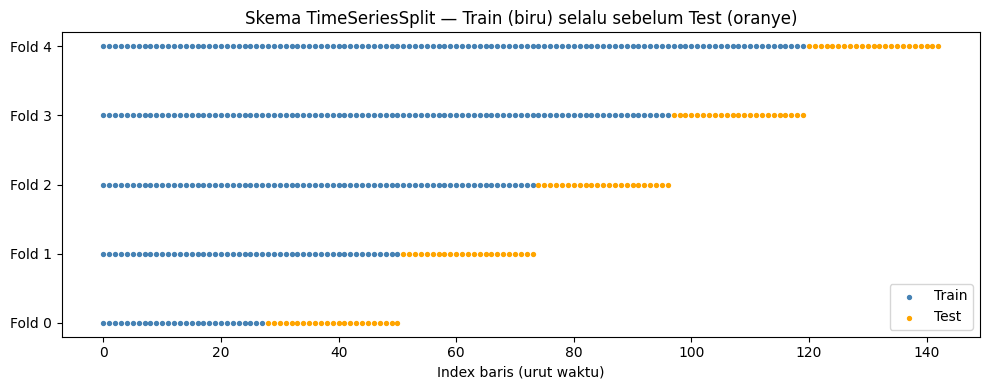

In [2]:
# Cell ini sudah lengkap — visualisasi supaya kamu lihat sendiri pola expanding window-nya.

tscv = TimeSeriesSplit(n_splits=5)

plt.figure(figsize=(10, 4))
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_full)):
    plt.scatter(train_idx, [fold] * len(train_idx), c="steelblue", s=8, label="Train" if fold == 0 else None)
    plt.scatter(test_idx, [fold] * len(test_idx), c="orange", s=8, label="Test" if fold == 0 else None)

plt.yticks(range(5), [f"Fold {i}" for i in range(5)])
plt.xlabel("Index baris (urut waktu)")
plt.title("Skema TimeSeriesSplit — Train (biru) selalu sebelum Test (oranye)")
plt.legend()
plt.tight_layout()
plt.show()

## Menjalankan Cross-Validation untuk Kedua Model

**Catatan penting soal scaling:** kita TIDAK bisa pakai `X_train_scaled.csv` di sini, karena file itu di-scale berdasarkan batas train/test dari Hari 13 — sedangkan sekarang batasnya beda-beda tiap fold. Solusinya: pakai `Pipeline` yang membungkus `StandardScaler` + `LinearRegression` jadi satu, supaya scaler di-fit ulang secara otomatis di dalam SETIAP fold, hanya dari data training fold itu.

*(Simplifikasi kecil: pipeline ini men-scale SEMUA kolom termasuk `bulan_*` yang biner. Ini sedikit menyimpang dari praktik pilih-pilih kolom di Hari 12, tapi dampaknya kecil — scaling kolom 0/1 cuma menggeser jadi dua nilai konstan, tidak merusak maknanya.)*

In [10]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Buat pipeline_linear = make_pipeline(StandardScaler(), LinearRegression())
# 2. Jalankan cross_val_score(pipeline_linear, X_full, y_full, cv=tscv,
#    scoring="neg_mean_absolute_error") — simpan hasilnya ke scores_linear
#    (hasilnya NEGATIF karena scikit-learn selalu "memaksimalkan" skor secara internal;
#    kalikan -1 supaya jadi MAE positif seperti biasa)
# 3. Jalankan cross_val_score(RandomForestRegressor(random_state=42), X_full, y_full,
#    cv=tscv, scoring="neg_mean_absolute_error") — simpan ke scores_rf, kalikan -1 juga
# 4. Cetak MAE per fold untuk kedua model (5 angka masing-masing)
# 5. Cetak rata-rata (.mean()) dan standar deviasi (.std()) MAE untuk kedua model —
#    ini estimasi performa yang lebih stabil dibanding cuma satu angka dari satu split
# Tulis kode kamu di bawah ini:
pipeline_linear = make_pipeline(StandardScaler(), LinearRegression())
scores_linear = cross_val_score(pipeline_linear, X_full, y_full, cv=tscv, scoring="neg_mean_absolute_error") * -1
scores_rf = cross_val_score(RandomForestRegressor(random_state=42), X_full, y_full, cv=tscv, scoring="neg_mean_absolute_error") * -1
print(f"MAE per fold Linear Regression: {scores_linear}")
print(f"MAE per fold Random Forest: {scores_rf}")
print()
print(f"rata-rata MAE per fold Linear Regression: {scores_linear.mean():.2f}")
print(f"rata-rata MAE per fold Random Forest: {scores_rf.mean():.2f}")
print()
print(f"Standar deviasi MAE per fold Linear Regression: {scores_linear.std():.2f}")
print(f"Standar deviasi MAE per fold Random Forest: {scores_rf.std():.2f}")

MAE per fold Linear Regression: [ 14714.99407193  40801.81565057 282551.49849893  23350.21586957
   3646.49584279]
MAE per fold Random Forest: [ 20468.66855072  70892.9457971  105208.69028986  79704.57202899
   7874.33826087]

rata-rata MAE per fold Linear Regression: 73013.00
rata-rata MAE per fold Random Forest: 56829.84

Standar deviasi MAE per fold Linear Regression: 105471.04
Standar deviasi MAE per fold Random Forest: 36824.76


Bandingkan rata-rata MAE cross-validation ini dengan angka MAE test tunggal dari Hari 16-17. Kalau selisihnya besar, itu artinya angka dari satu split kemarin memang agak "kebetulan" (bergantung pada periode mana yang jadi test set).

---
# BAGIAN B — Hari 20: Tuning Random Forest

Random Forest versi default (Hari 17) kalah dari Linear Regression, dan sempat menunjukkan gap kecil antara MAE train vs test. Mari coba batasi kompleksitasnya lewat `max_depth` dan `min_samples_leaf`, dicari otomatis pakai `GridSearchCV` — dengan `cv=TimeSeriesSplit`, BUKAN default 5-fold biasa (default `GridSearchCV` kalau tidak diberi `cv` akan pakai K-Fold acak — jebakan umum!).

In [5]:
# Cell ini sudah lengkap.
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 2, 4, 8],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=tscv,  # WAJIB TimeSeriesSplit, bukan default
    scoring="neg_mean_absolute_error",
)
grid_search.fit(X_full, y_full)

print("Kombinasi hyperparameter terbaik:", grid_search.best_params_)
print(f"MAE rata-rata cross-validation terbaik: {-grid_search.best_score_:,.0f}")

Kombinasi hyperparameter terbaik: {'max_depth': 7, 'min_samples_leaf': 2}
MAE rata-rata cross-validation terbaik: 53,165


## Evaluasi Random Forest Hasil Tuning di Split Asli (Hari 12-14)

Supaya bisa dibandingkan apple-to-apple dengan angka MAE test Linear Regression (7.806,56) dan Random Forest default (8.759,11) dari sebelumnya, kita evaluasi model hasil tuning ini di **split asli** yang sama (`X_train`/`X_test` dari Hari 12-14).

In [11]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Muat ulang X_train.csv, X_test.csv, y_train.csv, y_test.csv (split asli Hari 12-14)
# 2. Buat model Random Forest BARU pakai hyperparameter terbaik dari grid_search.best_params_
#    (bisa pakai RandomForestRegressor(random_state=42, **grid_search.best_params_))
# 3. Fit model itu ke X_train, y_train
# 4. Prediksi ke X_test, hitung MAE-nya dengan mean_absolute_error
# 5. Cetak MAE Random Forest hasil tuning, lalu bandingkan dengan:
#    - Random Forest default (8759.11)
#    - Linear Regression (7806.56)
#    Apakah tuning berhasil membuat Random Forest lebih baik dari Linear Regression?
# Tulis kode kamu di bawah ini:
X_train = pd.read_csv("X_train.csv", index_col=0, parse_dates=True)
X_test = pd.read_csv("X_test.csv", index_col=0, parse_dates=True)
y_train = pd.read_csv("y_train.csv", index_col=0, parse_dates=True).iloc[:, 0]
y_test = pd.read_csv("y_test.csv", index_col=0, parse_dates=True).iloc[:, 0]

model_rf_baru = RandomForestRegressor(random_state=42, **grid_search.best_params_).fit(X_train, y_train)
pred_rf_tuned = model_rf_baru.predict(X_test)
mae_rf_tuned = mean_absolute_error(y_test, pred_rf_tuned)
baseline_rf = 8759.11
baseline_linear = 7806.6
print(f"MAE Random Forest hasil tuning: {mae_rf_tuned:,.2f}")
print(f"Perbandingan: RF default = {baseline_rf:,.2f} | Linear Regression = {baseline_linear:,.2f}")

MAE Random Forest hasil tuning: 8,456.32
Perbandingan: RF default = 8,759.11 | Linear Regression = 7,806.60


## Refleksi Hari 19-20

> 1. Berapa rata-rata MAE cross-validation Linear Regression vs Random Forest (default)? Apakah urutannya sama dengan hasil single-split kemarin? → **73013.00 vs 56829.84**, tidak sama
> 2. Seberapa besar standar deviasi MAE antar fold untuk masing-masing model? Model dengan std lebih kecil berarti performanya lebih konsisten/stabil antar periode waktu → **Random Forest 36824.76, Linear Regression 105471.04**
> 3. Hyperparameter terbaik apa yang ditemukan `GridSearchCV`, dan apakah `max_depth`-nya jauh lebih kecil dari default (yang artinya tanpa batas)? → **max_depth, Ya**
> 4. Setelah tuning, apakah Random Forest berhasil mengalahkan Linear Regression di MAE test? → **tidak**
> 5. Berdasarkan SEMUA bukti sejauh ini (MAE single-split, MAE cross-validation, trend accuracy Hari 18, hasil tuning) — model mana yang condong kamu pilih sebagai final? → **Linear Regression**

---
### Selanjutnya: Hari 21 — Mini-Project Penutup Minggu 3

Kumpulkan semua bukti dari Hari 15-20 jadi satu **keputusan final**: model mana yang dipakai untuk proyek ini, dengan alasan yang terdokumentasi (bukan cuma "MAE paling rendah", tapi mempertimbangkan trend accuracy, stabilitas cross-validation, dan kesesuaian dengan business objective dari Hari 2). Setelah itu, lanjut ke Minggu 4: Evaluation formal & Deployment (Streamlit app sederhana).